In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [6]:
var_results = []

for fund_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    var_95 = np.percentile(returns, 5)

    cvar_95 = returns[returns <= var_95].mean()

    var_results.append({
        "amfi_code": fund_code,
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })

var_cvar = pd.DataFrame(var_results)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [7]:
var_cvar.shape

(40, 3)

In [8]:
fund_master = pd.read_csv(
    "../data/processed/fund_master_cleaned.csv"
)

var_cvar = var_cvar.merge(
    fund_master[["amfi_code", "scheme_name", "category", "risk_category"]],
    on="amfi_code",
    how="left"
)

In [9]:
var_cvar.to_csv(
    "../outputs/var_cvar_report.csv",
    index=False
)

In [10]:
var_cvar.sort_values("VaR_95").head(10)

,amfi_code,VaR_95,CVaR_95,scheme_name,category,risk_category
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth,Equity,Very High
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth,Equity,Very High
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth,Equity,Very High
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth,Equity,Very High
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth,Equity,Very High
39,149324,-0.023483,-0.031036,DSP Small Cap Fund - Regular - Growth,Equity,Very High
7,102886,-0.019220,-0.023251,UTI Mid Cap Fund - Regular - Growth,Equity,High
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,High
25,120505,-0.018892,-0.024342,ICICI Pru Midcap Fund - Regular - Growth,Equity,High
16,119094,-0.018480,-0.024260,Axis Midcap Fund - Regular - Growth,Equity,High


In [11]:
nav["daily_return"]

0             NaN
1       -0.010306
2        0.012865
3       -0.011377
4       -0.001210
           ...   
45995    0.012106
45996   -0.004138
45997   -0.008480
45998   -0.028093
45999   -0.003335
Name: daily_return, Length: 46000, dtype: float64

In [12]:
key_funds = [
    119551,  # SBI Bluechip
    120503,  # ICICI Bluechip
    118632,  # Nippon Large Cap
    119092,  # Axis Bluechip
    120841   # Kotak Bluechip
]

In [13]:
rolling_data = nav[
    nav["amfi_code"].isin(key_funds)
].copy()

rolling_data = rolling_data.sort_values(
    ["amfi_code", "date"]
)

rolling_data["rolling_sharpe_90d"] = (
    rolling_data
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x:
        x.rolling(90).mean()
        / x.rolling(90).std()
        * np.sqrt(252)
    )
)

rolling_data.head()

,amfi_code,date,nav,daily_return,rolling_sharpe_90d
10350,118632,2022-01-03,42.8339,NaN,NaN
10351,118632,2022-01-04,42.8033,-0.000714,NaN
10352,118632,2022-01-05,43.0564,0.005913,NaN
10353,118632,2022-01-06,43.2088,0.003540,NaN
10354,118632,2022-01-07,42.9585,-0.005793,NaN


In [14]:
rolling_data[
    ["amfi_code", "date", "rolling_sharpe_90d"]
].tail()

,amfi_code,date,rolling_sharpe_90d
33345,120841,2026-05-25,2.427230
33346,120841,2026-05-26,2.355138
33347,120841,2026-05-27,2.240101
33348,120841,2026-05-28,2.324704
33349,120841,2026-05-29,2.167518


In [15]:
rolling_data = rolling_data.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [16]:
rolling_data[
    ["date", "scheme_name", "rolling_sharpe_90d"]
].tail()

,date,scheme_name,rolling_sharpe_90d
5745,2026-05-25,Kotak Bluechip Fund - Regular - Growth,2.427230
5746,2026-05-26,Kotak Bluechip Fund - Regular - Growth,2.355138
5747,2026-05-27,Kotak Bluechip Fund - Regular - Growth,2.240101
5748,2026-05-28,Kotak Bluechip Fund - Regular - Growth,2.324704
5749,2026-05-29,Kotak Bluechip Fund - Regular - Growth,2.167518


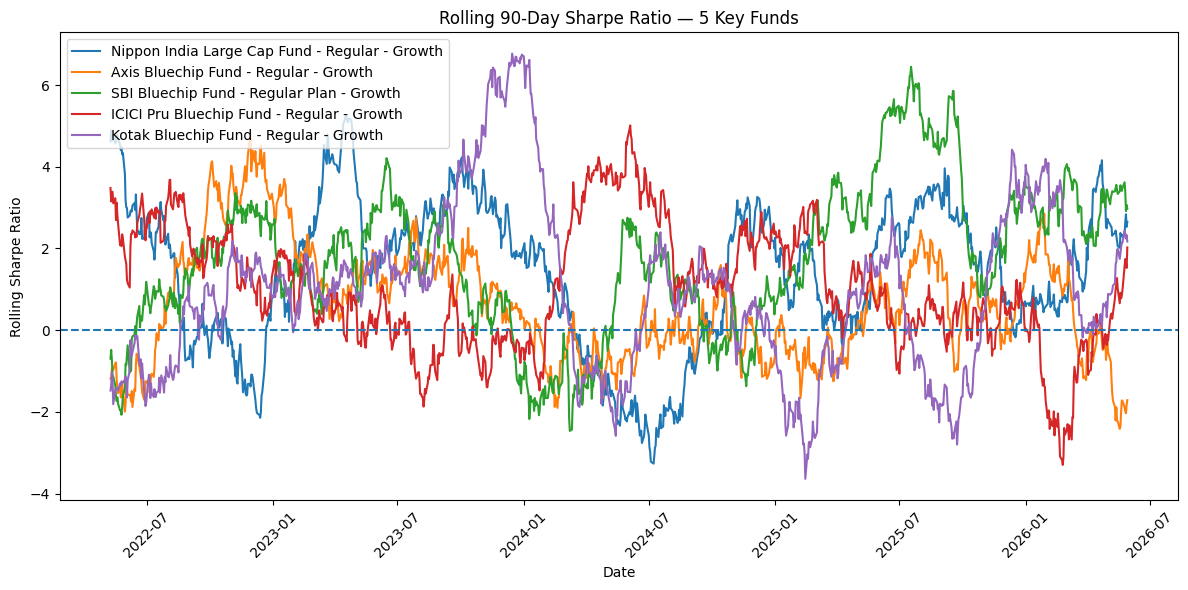

In [17]:
plt.figure(figsize=(12, 6))

for fund in rolling_data["scheme_name"].dropna().unique():
    temp = rolling_data[
        rolling_data["scheme_name"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe_90d"],
        label=fund
    )

plt.axhline(0, linestyle="--")
plt.title("Rolling 90-Day Sharpe Ratio — 5 Key Funds")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [18]:
plt.savefig(
    "../outputs/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [19]:
investor = pd.read_csv(
    "../data/processed/investor_transactions_cleaned.csv"
)

investor["transaction_date"] = pd.to_datetime(
    investor["transaction_date"]
)

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [20]:
first_transaction = (
    investor
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction["cohort_year"] = (
    first_transaction["transaction_date"].dt.year
)

first_transaction.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [21]:
investor = investor.merge(
    first_transaction[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

In [22]:
investor[
    ["investor_id", "transaction_date", "cohort_year"]
].head()

,investor_id,transaction_date,cohort_year
0,INV003054,2024-01-01,2024
1,INV002952,2024-01-01,2024
2,INV003420,2024-01-01,2024
3,INV003436,2024-01-01,2024
4,INV004691,2024-01-01,2024


In [23]:
sip_cohort = (
    investor[investor["transaction_type"] == "SIP"]
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_sip_amount")
)

In [24]:
invested_cohort = (
    investor[
        investor["transaction_type"].isin(
            ["SIP", "Lumpsum"]
        )
    ]
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested")
)

In [25]:
fund_preference = (
    investor
    .groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(name="transaction_count")
)

In [26]:
top_funds = (
    fund_preference
    .sort_values(
        ["cohort_year", "transaction_count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

In [27]:
cohort_analysis = (
    sip_cohort
    .merge(
        invested_cohort,
        on="cohort_year",
        how="outer"
    )
    .merge(
        top_funds[
            ["cohort_year", "amfi_code", "transaction_count"]
        ],
        on="cohort_year",
        how="left"
    )
)

cohort_analysis

,cohort_year,avg_sip_amount,total_invested,amfi_code,transaction_count
0,2024,10996.885825,2258062304,148568,874
1,2025,13505.209581,18992635,119599,12


In [28]:
cohort_analysis = cohort_analysis.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [29]:
cohort_analysis

,cohort_year,avg_sip_amount,total_invested,amfi_code,transaction_count,scheme_name
0,2024,10996.885825,2258062304,148568,874,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,13505.209581,18992635,119599,12,SBI Small Cap Fund - Direct Plan - Growth


In [30]:
sip = investor[
    investor["transaction_type"] == "SIP"
].copy()

sip["transaction_date"] = pd.to_datetime(
    sip["transaction_date"]
)

sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [31]:
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

In [32]:
sip[
    ["investor_id", "transaction_date", "gap_days"]
].head(15)

,investor_id,transaction_date,gap_days
19621,INV000001,2024-11-04,NaN
24448,INV000001,2025-01-19,76.0
5650,INV000002,2024-03-29,NaN
16803,INV000002,2024-09-21,176.0
31881,INV000002,2025-05-17,238.0
12652,INV000003,2024-07-16,NaN
27622,INV000003,2025-03-11,238.0
4773,INV000004,2024-03-16,NaN
6418,INV000004,2024-04-11,26.0
8271,INV000004,2024-05-09,28.0


In [33]:
sip_counts = (
    sip.groupby("investor_id")
       .size()
       .reset_index(name="sip_count")
)

eligible_investors = sip_counts[
    sip_counts["sip_count"] >= 6
]

eligible_investors.head()

,investor_id,sip_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


In [34]:
sip_gap = (
    sip.groupby("investor_id")["gap_days"]
       .mean()
       .reset_index(name="avg_gap_days")
)

In [35]:
sip_gap = sip_gap.merge(
    eligible_investors,
    on="investor_id",
    how="inner"
)

In [36]:
sip_gap["continuity_status"] = np.where(
    sip_gap["avg_gap_days"] > 35,
    "At-Risk",
    "Regular"
)

In [37]:
sip_gap.head(10)

,investor_id,avg_gap_days,sip_count,continuity_status
0,INV000004,85.400000,6,At-Risk
1,INV000008,70.400000,6,At-Risk
2,INV000010,64.800000,6,At-Risk
3,INV000011,40.166667,7,At-Risk
4,INV000012,57.000000,8,At-Risk
5,INV000013,55.333333,7,At-Risk
6,INV000014,75.333333,7,At-Risk
7,INV000023,58.571429,8,At-Risk
8,INV000028,93.600000,6,At-Risk
9,INV000029,60.666667,7,At-Risk


In [38]:
total_eligible = len(sip_gap)

at_risk = (
    sip_gap["continuity_status"] == "At-Risk"
).sum()

at_risk_rate = (
    at_risk / total_eligible * 100
)

continuity_rate = 100 - at_risk_rate

print("Eligible investors:", total_eligible)
print("At-risk investors:", at_risk)
print("At-risk rate:", round(at_risk_rate, 2), "%")
print("SIP continuity rate:", round(continuity_rate, 2), "%")

Eligible investors: 1362
At-risk investors: 1332
At-risk rate: 97.8 %
SIP continuity rate: 2.2 %


In [39]:
fund_master["risk_category"].unique()

array(['Moderate', 'Very High', 'Low', 'High', 'Moderately High'],
      dtype=object)

In [40]:
performance = pd.read_csv(
    "../data/processed/scheme_performance_cleaned.csv"
)

print(performance.columns.tolist())
print(performance["risk_grade"].unique())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']
['Moderate' 'Very High' 'Low' 'High' 'Moderately High']


In [41]:
import os

for file in os.listdir("../data/processed"):
    print(file)

02_nav_history_cleaned.csv
aum_cleaned.csv
benchmark_indices_cleaned.csv
category_inflows_cleaned.csv
fund_master_cleaned.csv
industry_folio_count_cleaned.csv
investor_transactions_cleaned.csv
monthly_sip_inflows_cleaned.csv
portfolio_holdings_cleaned.csv
scheme_performance_cleaned.csv


In [42]:
portfolio = pd.read_csv(
    "../data/processed/portfolio_holdings_cleaned.csv"
)

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [43]:
portfolio.columns.tolist()

['amfi_code',
 'stock_symbol',
 'stock_name',
 'sector',
 'weight_pct',
 'market_value_cr',
 'current_price_inr',
 'portfolio_date']

In [44]:
hhi = (
    portfolio
    .groupby("amfi_code")
    .apply(
        lambda x: ((x["weight_pct"] / 100) ** 2).sum()
    )
    .reset_index(name="HHI")
)

C:\Users\Keerthana\AppData\Local\Temp\ipykernel_9468\3398919069.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [45]:
hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [46]:
hhi = hhi.merge(
    fund_master[["amfi_code", "scheme_name", "category"]],
    on="amfi_code",
    how="left"
)

In [47]:
hhi.sort_values("HHI", ascending=False).head(10)

,amfi_code,HHI,scheme_name,category
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Equity
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Equity


In [48]:
equity_hhi = hhi[
    hhi["category"].str.contains(
        "Equity",
        case=False,
        na=False
    )
].sort_values(
    "HHI",
    ascending=False
)

equity_hhi.head(10)

,amfi_code,HHI,scheme_name,category
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Equity
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Equity


## Advanced Analytics Insights

In [49]:
var_cvar.sort_values("VaR_95").head(5)

,amfi_code,VaR_95,CVaR_95,scheme_name,category,risk_category
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth,Equity,Very High
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth,Equity,Very High
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth,Equity,Very High
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth,Equity,Very High
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth,Equity,Very High


In [50]:
cohort_analysis.sort_values("total_invested", ascending=False)

,cohort_year,avg_sip_amount,total_invested,amfi_code,transaction_count,scheme_name
0,2024,10996.885825,2258062304,148568,874,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,13505.209581,18992635,119599,12,SBI Small Cap Fund - Direct Plan - Growth


In [51]:
print("Eligible investors:", len(sip_gap))
print("At-risk investors:", (sip_gap["continuity_status"] == "At-Risk").sum())
print("At-risk rate:", round(at_risk_rate, 2), "%")
print("Continuity rate:", round(continuity_rate, 2), "%")

Eligible investors: 1362
At-risk investors: 1332
At-risk rate: 97.8 %
Continuity rate: 2.2 %


In [52]:
for risk in ["Low", "Moderate", "High"]:
    print("\n", risk)
    filtered = performance[
        performance["risk_grade"].str.title() == risk
    ].sort_values("sharpe_ratio", ascending=False).head(3)

    print(
        filtered[
            ["scheme_name", "risk_grade", "sharpe_ratio"]
        ].to_string(index=False)
    )


 Low
                             scheme_name risk_grade  sharpe_ratio
ICICI Pru Liquid Fund - Regular - Growth        Low          7.68
    Kotak Liquid Fund - Regular - Growth        Low          6.18
     ABSL Liquid Fund - Regular - Growth        Low          5.14

 Moderate
                                  scheme_name risk_grade  sharpe_ratio
    HDFC Top 100 Fund - Regular Plan - Growth   Moderate          1.06
Mirae Asset Large Cap Fund - Regular - Growth   Moderate          1.06
    ICICI Pru Bluechip Fund - Direct - Growth   Moderate          1.03

 High
                                  scheme_name risk_grade  sharpe_ratio
Kotak Emerging Equity Fund - Regular - Growth       High          0.96
     ICICI Pru Midcap Fund - Regular - Growth       High          0.95
           DSP Midcap Fund - Regular - Growth       High          0.90


In [53]:
equity_hhi.head(5)

,amfi_code,HHI,scheme_name,category
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity


In [ ]:
## Advanced Analytics Insights

### 1. Historical VaR and CVaR — Downside Risk

The Historical VaR analysis shows that the **SBI Small Cap Fund - Direct Plan - Growth** had the highest downside risk among the 40 schemes, with a 95% VaR of **-2.69%** and a CVaR of **-3.24%**. This means that on the worst 5% of trading days, the fund's daily losses were at least around 2.69%, while the average loss beyond the VaR threshold was approximately 3.24%.

The other funds with the highest downside risk were **Axis Small Cap Fund - Regular - Growth** (VaR: -2.62%), **ABSL Small Cap Fund - Regular - Growth** (VaR: -2.60%), and **Nippon India Small Cap Fund - Regular - Growth** (VaR: -2.54%). All five funds with the highest downside risk belong to the **Very High** risk category and are small-cap equity funds, indicating greater downside volatility in this segment.


### 2. Investor Cohort Analysis

The investor cohort analysis shows a significant difference in investment activity between the 2024 and 2025 cohorts. The **2024 cohort** recorded total investments of approximately **₹225.81 crore**, with an average SIP amount of approximately **₹10,997**. The cohort's most preferred fund was **Mirae Asset Emerging Bluechip Fund - Regular Plan - Growth**, with **874 transactions**.

In comparison, the **2025 cohort** recorded total investments of approximately **₹1.90 crore**, with a higher average SIP amount of approximately **₹13,505**. Its top fund preference was **SBI Small Cap Fund - Direct Plan - Growth**. Although the 2025 cohort had a higher average SIP amount, the 2024 cohort contributed substantially more to total invested value.


### 3. SIP Continuity and At-Risk Investors

The SIP continuity analysis identified **1,362 investors** with at least six SIP transactions. Among them, **1,332 investors (97.8%)** were classified as **at-risk** because their average gap between SIP transactions exceeded 35 days. Only **30 investors (2.2%)** maintained an average SIP gap of 35 days or less.

This indicates a very low SIP continuity rate in the analyzed dataset and highlights a potential investor-retention concern. A large proportion of recurring investors may require engagement measures such as SIP reminders, follow-up communication, or retention campaigns to improve investment continuity.


### 4. Risk-Based Fund Recommendation

The fund recommender identifies different top-performing funds for each risk appetite based on Sharpe ratio. For the **Low-risk** category, **ICICI Pru Liquid Fund - Regular - Growth** ranked first with a Sharpe ratio of **7.68**, followed by **Kotak Liquid Fund - Regular - Growth** (6.18) and **ABSL Liquid Fund - Regular - Growth** (5.14).

For the **Moderate-risk** category, **HDFC Top 100 Fund - Regular Plan - Growth** and **Mirae Asset Large Cap Fund - Regular - Growth** jointly recorded the highest Sharpe ratio of **1.06**, followed by **ICICI Pru Bluechip Fund - Direct - Growth** at **1.03**. In the **High-risk** category, **Kotak Emerging Equity Fund - Regular - Growth** ranked highest with a Sharpe ratio of **0.96**, followed by **ICICI Pru Midcap Fund - Regular - Growth** at **0.95**.

Overall, the recommender demonstrates how investors can receive different fund recommendations based on their risk appetite while prioritizing risk-adjusted performance.


### 5. Sector HHI Concentration

The Sector HHI analysis shows that **Axis Bluechip Fund - Regular - Growth** has the highest sector concentration among the analyzed equity funds, with an HHI of **0.2064**. It is followed by **ABSL Small Cap Fund - Regular - Growth** with an HHI of **0.2007** and **SBI Small Cap Fund - Direct Plan - Growth** with **0.1748**.

The results indicate that these funds have relatively higher portfolio concentration across sectors compared with the other analyzed equity funds. **UTI Nifty 50 Index Fund - Regular - Growth** and **Nippon India Large Cap Fund - Regular - Growth** recorded HHI values of **0.1747** and **0.1683**, respectively. A higher HHI indicates greater concentration, while a lower HHI generally indicates more diversified sector exposure.